# GBM Simulation

(This notebook documents my practice of methods in continuous time finance. While I have taken care going through the code, there may be errors or inefficiencies. This is the nature of learning, and I will be sure to keep updating this notebook as my understanding develops)

$$
S_{t} = S_{0}e^{\mu t \: + \: \sigma Z_{t}}
$$

This is our equation for GBM. We start with log shocks, we assume are iid, using CLT result and Donsker's theorem we can say our sum of (log) shocks converge to Brownian motion, exponentiating we get equation for GBM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def path(s0, r, sigma, T, t, n):

    dt  = T/t

    S = np.zeros((t+1, n))
    S[0] = s0

    for i in range(1, t+1):
        z = np.random.standard_normal(n)
        S[i] = S[i-1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)

    return S


Brownian motion when steps tend to 0, continuous but differentiable nowhere, we can visualise how the price could have evolved.

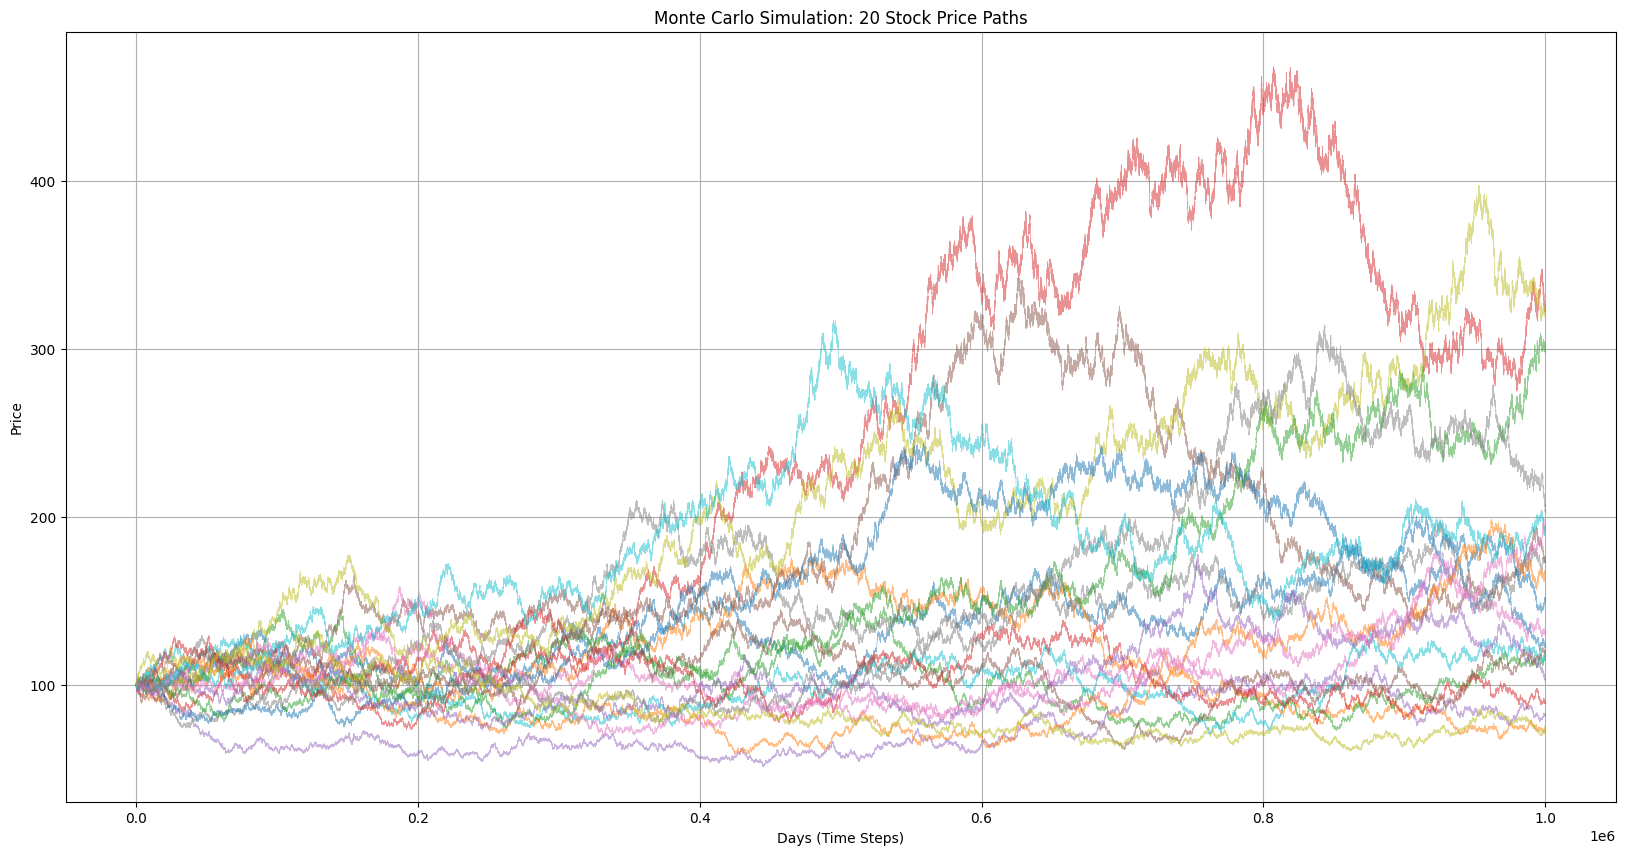

In [4]:
price_path = pd.DataFrame(path(100, 0.05, 0.20, 10, 1000000, 100))
price_path.tail()

plt.figure(figsize=(20, 10))
plt.plot(price_path.iloc[:, :20], alpha=0.5, lw = 0.5) 
plt.title('Monte Carlo Simulation: 20 Stock Price Paths')
plt.xlabel('Days (Time Steps)')
plt.ylabel('Price')
plt.grid(True)
plt.show()
